# MSI5102 Project: Handwritten Digit Recognition (MNIST) 
## Full Search And Training

This project implements and compares multiple machine learning models for classifying handwritten digits from the MNIST dataset.

**Models implemented:**
1. k-Nearest Neighbors (KNN)
2. Logistic Regression
3. Neural Network (MLP & CNN)

**Additional features:**
- Dimensionality reduction & visualization (PCA, t-SNE)
- Hyperparameter optimization for each model
- Compatible with MacBook Apple Silicon (MPS) and Kaggle Free GPU (CUDA)

**Updates:**
- KNN and Logistic Regression search on the full training set with 5-fold `GridSearchCV`
- PCA search space changed to retained variance ratios `[0.90, 0.95, 0.99]`
- Full `cv_results_` tables and parameter-comparison visualizations for KNN and LR
- Configurable early stopping for MLP and CNN with a global switch and model-specific defaults
- New output artifact names ending in `_v2` to avoid overwriting existing tracked files
- Use adamW as Optimizer

Running the full notebook will take substantially longer than the original notebook because the traditional-model search now uses the full training data and 5-fold CV.

## 1. Setup, Reproducibility, and Global Configuration

This section defines imports, device detection, reproducibility settings, output file names, caching, and the search / training configuration used throughout the notebook.

In [26]:
import copy
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from joblib import Memory, dump
from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')

# Reproducibility seed used across NumPy and PyTorch.
SEED = 42

# Output directory for all generated figures.
PROJECT_ROOT = Path('./MNIST-MSI') if Path.cwd().name != 'MNIST-MSI' else Path('.')
OUTPUT_DIR = PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# PCA retained-variance candidates used in traditional-model search.
PCA_SEARCH_SPACE = [0.90, 0.95, 0.99]

# Global early-stopping switches shared by MLP and CNN.
USE_EARLY_STOPPING = False
RESTORE_BEST_WEIGHTS = True
MIN_EPOCHS = 5

# Shared neural-network optimization hyperparameters.
NN_EPOCHS = 40
NN_LR = 0.0005
NN_OPTIMIZER_NAME = 'AdamW'
NN_WEIGHT_DECAY = 5e-5
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using Apple Silicon MPS')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using CUDA GPU: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('Using CPU')

def sync_device():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()

OUTPUT_FILES = {
    'knn_heatmap': str(OUTPUT_DIR / 'knn_gridsearch_all_results_v2.png'),
    'knn_lines': str(OUTPUT_DIR / 'knn_gridsearch_lineplot_v2.png'),
    'knn_k_curve': str(OUTPUT_DIR / 'knn_k_vs_cv_accuracy_v2.png'),
    'knn_cv_results_raw': str(OUTPUT_DIR / 'knn_cv_results_raw_v2.csv'),
    'knn_full_table': str(OUTPUT_DIR / 'knn_cv_results_full_v2.csv'),
    'knn_ranked_table': str(OUTPUT_DIR / 'knn_cv_results_ranked_v2.csv'),
    'knn_search_summary': str(OUTPUT_DIR / 'knn_search_summary_v2.json'),
    'knn_best_estimator': str(OUTPUT_DIR / 'knn_best_estimator_v2.joblib'),
    'lr_heatmap': str(OUTPUT_DIR / 'lr_gridsearch_all_results_v2.png'),
    'lr_lines': str(OUTPUT_DIR / 'lr_gridsearch_lineplot_v2.png'),
    'lr_cv_results_raw': str(OUTPUT_DIR / 'lr_cv_results_raw_v2.csv'),
    'lr_full_table': str(OUTPUT_DIR / 'lr_cv_results_full_v2.csv'),
    'lr_ranked_table': str(OUTPUT_DIR / 'lr_cv_results_ranked_v2.csv'),
    'lr_search_summary': str(OUTPUT_DIR / 'lr_search_summary_v2.json'),
    'lr_best_estimator': str(OUTPUT_DIR / 'lr_best_estimator_v2.joblib'),
    'model_comparison': str(OUTPUT_DIR / 'model_comparison_v2.png'),
    'nn_curves': str(OUTPUT_DIR / 'nn_training_curves_v2.png'),
    'confusion_matrices': str(OUTPUT_DIR / 'confusion_matrices_v2.png'),
}

CACHE_DIR = Path('.cache/sklearn_mnist_full_search_v2')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
pipeline_memory = Memory(location=CACHE_DIR, verbose=0)

# Cross-validation settings for GridSearchCV.
SEARCH_KWARGS = {
    'cv': 5,
    'scoring': 'accuracy',
    'n_jobs': -1,
    'verbose': 1,
    'refit': True,
}

# KNN hyperparameter search space.
KNN_PARAM_GRID = {
    'pca__n_components': PCA_SEARCH_SPACE,
    'knn__n_neighbors': [1, 3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan'],
}

# Logistic Regression hyperparameter search space.
LR_PARAM_GRID = {
    'pca__n_components': PCA_SEARCH_SPACE,
    'lr__C': [0.01, 0.1, 1.0, 10.0],
    'lr__solver': ['lbfgs', 'saga'],
    'lr__penalty': ['l2'],
}

# MLP early-stopping configuration.
MLP_EARLY_STOP_CONFIG = {
    'use_early_stopping': USE_EARLY_STOPPING,
    'monitor': 'val_acc',
    'mode': 'max',
    'min_delta': 0.000333,
    'patience': 8,
    'restore_best_weights': RESTORE_BEST_WEIGHTS,
    'min_epochs': MIN_EPOCHS,
}

# CNN early-stopping configuration.
CNN_EARLY_STOP_CONFIG = {
    'use_early_stopping': USE_EARLY_STOPPING,
    'monitor': 'val_acc',
    'mode': 'max',
    'min_delta': 0.000333,
    'patience': 12,
    'restore_best_weights': RESTORE_BEST_WEIGHTS,
    'min_epochs': MIN_EPOCHS,
}

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 120)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f'Device: {device}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')
print(f'Cache directory: {CACHE_DIR.resolve()}')
print('Output files:')
for key, value in OUTPUT_FILES.items():
    print(f'  - {key}: {value}')
print('MLP early stop config:', MLP_EARLY_STOP_CONFIG)
print('CNN early stop config:', CNN_EARLY_STOP_CONFIG)

Using Apple Silicon MPS
Device: mps
Output directory: /Users/jiejia/Programs/MNIST-MSI/output
Cache directory: /Users/jiejia/Programs/MNIST-MSI/.cache/sklearn_mnist_full_search_v2
Output files:
  - knn_heatmap: output/knn_gridsearch_all_results_v2.png
  - knn_lines: output/knn_gridsearch_lineplot_v2.png
  - knn_k_curve: output/knn_k_vs_cv_accuracy_v2.png
  - knn_cv_results_raw: output/knn_cv_results_raw_v2.csv
  - knn_full_table: output/knn_cv_results_full_v2.csv
  - knn_ranked_table: output/knn_cv_results_ranked_v2.csv
  - knn_search_summary: output/knn_search_summary_v2.json
  - knn_best_estimator: output/knn_best_estimator_v2.joblib
  - lr_heatmap: output/lr_gridsearch_all_results_v2.png
  - lr_lines: output/lr_gridsearch_lineplot_v2.png
  - lr_cv_results_raw: output/lr_cv_results_raw_v2.csv
  - lr_full_table: output/lr_cv_results_full_v2.csv
  - lr_ranked_table: output/lr_cv_results_ranked_v2.csv
  - lr_search_summary: output/lr_search_summary_v2.json
  - lr_best_estimator: output/

## 2. Data Loading and Split

Load MNIST, normalize to `[0, 1]`, then create the same `60000 / 10000` train-test split used by the original project.

In [27]:
print('Loading MNIST dataset...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data.astype('float32') / 255.0
y = mnist.target.astype('int64')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=10000,
    random_state=SEED,
    stratify=y,
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Feature size: {X_train.shape[1]}')
print(f'Classes:      {np.unique(y_train)}')

Loading MNIST dataset...
Training set: 60000 samples
Test set:     10000 samples
Feature size: 784
Classes:      [0 1 2 3 4 5 6 7 8 9]


## 3. Shared Helpers for Search, Evaluation, and Visualization

These helpers are used by the traditional models and the neural-network training loop.

In [28]:
results = {}
traditional_search_summaries = []

def to_python_scalar(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value

def normalize_params(params):
    return {key: to_python_scalar(value) for key, value in params.items()}

def params_to_string(params):
    return json.dumps(normalize_params(params), sort_keys=True)

def build_knn_pipeline(memory):
    return Pipeline(
        steps=[
            ('pca', PCA(svd_solver='full', random_state=SEED)),
            ('knn', KNeighborsClassifier()),
        ],
        memory=memory,
    )

def build_lr_pipeline(memory):
    return Pipeline(
        steps=[
            ('pca', PCA(svd_solver='full', random_state=SEED)),
            ('lr', LogisticRegression(max_iter=2000, random_state=SEED)),
        ],
        memory=memory,
    )

def prepare_cv_tables(cv_results_df):
    param_cols = [col for col in cv_results_df.columns if col.startswith('param_')]
    keep_cols = param_cols + [
        'mean_test_score',
        'std_test_score',
        'rank_test_score',
        'mean_fit_time',
        'std_fit_time',
    ]
    full_table = cv_results_df[keep_cols].copy()
    for col in param_cols:
        full_table[col] = full_table[col].map(to_python_scalar)
    full_table = full_table.reset_index(drop=True)
    ranked_table = full_table.sort_values(
        ['rank_test_score', 'mean_test_score', 'mean_fit_time'],
        ascending=[True, False, True],
    ).reset_index(drop=True)
    return full_table, ranked_table

def save_grid_search_outputs(model_key, model_name, search_result):
    cv_results_df = search_result['cv_results_df']
    full_table = search_result['full_table']
    ranked_table = search_result['ranked_table']
    grid = search_result['grid']

    cv_results_df.to_csv(OUTPUT_FILES[f'{model_key}_cv_results_raw'], index=False)
    full_table.to_csv(OUTPUT_FILES[f'{model_key}_full_table'], index=False)
    ranked_table.to_csv(OUTPUT_FILES[f'{model_key}_ranked_table'], index=False)
    dump(grid.best_estimator_, OUTPUT_FILES[f'{model_key}_best_estimator'])

    summary_payload = {
        'model_name': model_name,
        'best_params': normalize_params(grid.best_params_),
        'best_cv_accuracy': float(grid.best_score_),
        'search_time_seconds': float(search_result['search_time']),
        'refit_time_seconds': float(search_result['refit_time']),
        'total_time_seconds': float(search_result['total_time']),
        'cv_folds': int(SEARCH_KWARGS['cv']),
        'scoring': SEARCH_KWARGS['scoring'],
        'num_parameter_combinations': int(len(cv_results_df)),
    }
    Path(OUTPUT_FILES[f'{model_key}_search_summary']).write_text(
        json.dumps(summary_payload, indent=2),
        encoding='utf-8',
    )

    print(f"Saved {model_name} search artifacts to: {OUTPUT_DIR.resolve()}")
    print(f"  - raw cv_results: {OUTPUT_FILES[f'{model_key}_cv_results_raw']}")
    print(f"  - cleaned full table: {OUTPUT_FILES[f'{model_key}_full_table']}")
    print(f"  - ranked table: {OUTPUT_FILES[f'{model_key}_ranked_table']}")
    print(f"  - summary json: {OUTPUT_FILES[f'{model_key}_search_summary']}")
    print(f"  - best estimator: {OUTPUT_FILES[f'{model_key}_best_estimator']}")

def run_grid_search(model_name, model_key, pipeline, param_grid, X, y):
    print('=' * 80)
    print(f'Running {model_name} GridSearchCV on the full training set...')
    print('=' * 80)
    sync_device()
    t_start = time.time()
    grid = GridSearchCV(pipeline, param_grid, **SEARCH_KWARGS)
    grid.fit(X, y)
    sync_device()
    total_time = time.time() - t_start
    refit_time = float(getattr(grid, 'refit_time_', 0.0))
    search_time = max(0.0, total_time - refit_time)
    cv_results_df = pd.DataFrame(grid.cv_results_)
    full_table, ranked_table = prepare_cv_tables(cv_results_df)

    print(f'Best parameters: {normalize_params(grid.best_params_)}')
    print(f'Best CV accuracy: {grid.best_score_:.4f}')
    print(f'GridSearchCV total time: {total_time:.2f}s')
    print(f'Estimated CV-only search time: {search_time:.2f}s')
    print(f'GridSearchCV internal refit time: {refit_time:.2f}s')
    print('Best estimator:')
    print(grid.best_estimator_)

    search_result = {
        'grid': grid,
        'cv_results_df': cv_results_df,
        'full_table': full_table,
        'ranked_table': ranked_table,
        'search_time': search_time,
        'refit_time': refit_time,
        'total_time': total_time,
    }
    save_grid_search_outputs(model_key, model_name, search_result)
    return search_result

def evaluate_model(name, y_true, y_pred, train_time, predict_time):
    acc = accuracy_score(y_true, y_pred)
    results[name] = {
        'accuracy': acc,
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
    }
    print('\n' + '=' * 60)
    print(f'{name} - Test Accuracy: {acc:.4f} ({acc * 100:.2f}%)')
    print(f'Training time: {train_time:.2f}s | Prediction time: {predict_time:.2f}s')
    print('=' * 60)
    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred))

def plot_knn_search(cv_results_df):
    plot_df = cv_results_df[[
        'param_pca__n_components',
        'param_knn__n_neighbors',
        'param_knn__weights',
        'param_knn__metric',
        'mean_test_score',
    ]].copy()
    plot_df['param_pca__n_components'] = plot_df['param_pca__n_components'].astype(float)
    plot_df['param_knn__n_neighbors'] = plot_df['param_knn__n_neighbors'].astype(int)
    plot_df['group'] = plot_df['param_knn__metric'].astype(str) + ' / ' + plot_df['param_knn__weights'].astype(str)
    pca_values = sorted(plot_df['param_pca__n_components'].unique())
    k_values = sorted(plot_df['param_knn__n_neighbors'].unique())

    fig, axes = plt.subplots(1, len(pca_values), figsize=(6 * len(pca_values), 5), sharey=True)
    if len(pca_values) == 1:
        axes = [axes]
    for ax, pca_value in zip(axes, pca_values):
        subset = plot_df[plot_df['param_pca__n_components'] == pca_value]
        pivot = subset.pivot_table(index='group', columns='param_knn__n_neighbors', values='mean_test_score')
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis', ax=ax)
        ax.set_title(f'KNN mean CV accuracy\nPCA retain={pca_value:.2f}')
        ax.set_xlabel('n_neighbors')
        ax.set_ylabel('metric / weights')
    plt.tight_layout()
    plt.savefig(OUTPUT_FILES['knn_heatmap'], dpi=150, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, len(pca_values), figsize=(6 * len(pca_values), 4), sharey=True)
    if len(pca_values) == 1:
        axes = [axes]
    for ax, pca_value in zip(axes, pca_values):
        subset = plot_df[plot_df['param_pca__n_components'] == pca_value]
        for group_name, group_df in subset.groupby('group'):
            group_df = group_df.sort_values('param_knn__n_neighbors')
            ax.plot(
                group_df['param_knn__n_neighbors'],
                group_df['mean_test_score'],
                marker='o',
                label=group_name,
            )
        ax.set_title(f'KNN line view\nPCA retain={pca_value:.2f}')
        ax.set_xlabel('n_neighbors')
        ax.set_ylabel('mean CV accuracy')
        ax.set_xticks(k_values)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_FILES['knn_lines'], dpi=150, bbox_inches='tight')
    plt.show()

    k_curve_df = (
        plot_df.groupby(['param_pca__n_components', 'param_knn__n_neighbors'])['mean_test_score']
        .max()
        .reset_index()
        .sort_values(['param_pca__n_components', 'param_knn__n_neighbors'])
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for pca_value, subset in k_curve_df.groupby('param_pca__n_components'):
        ax.plot(
            subset['param_knn__n_neighbors'],
            subset['mean_test_score'],
            marker='o',
            linewidth=2,
            label=f'PCA retain={pca_value:.2f}',
        )
    ax.set_title('KNN: k vs Best CV Accuracy by PCA Retention')
    ax.set_xlabel('k (Number of Neighbors)')
    ax.set_ylabel('Best Mean CV Accuracy')
    ax.set_xticks(k_values)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_FILES['knn_k_curve'], dpi=150, bbox_inches='tight')
    plt.show()

def plot_lr_search(cv_results_df):
    plot_df = cv_results_df[[
        'param_pca__n_components',
        'param_lr__C',
        'param_lr__solver',
        'mean_test_score',
    ]].copy()
    plot_df['param_pca__n_components'] = plot_df['param_pca__n_components'].astype(float)
    plot_df['param_lr__C'] = plot_df['param_lr__C'].astype(float)
    pca_values = sorted(plot_df['param_pca__n_components'].unique())
    c_values = sorted(plot_df['param_lr__C'].unique())

    fig, axes = plt.subplots(1, len(pca_values), figsize=(6 * len(pca_values), 4.5), sharey=True)
    if len(pca_values) == 1:
        axes = [axes]
    for ax, pca_value in zip(axes, pca_values):
        subset = plot_df[plot_df['param_pca__n_components'] == pca_value].copy()
        subset['param_lr__C'] = subset['param_lr__C'].map(lambda value: f'{value:g}')
        pivot = subset.pivot_table(index='param_lr__solver', columns='param_lr__C', values='mean_test_score')
        pivot = pivot[[f'{value:g}' for value in c_values]]
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='magma', ax=ax)
        ax.set_title(f'LR mean CV accuracy\nPCA retain={pca_value:.2f}')
        ax.set_xlabel('C')
        ax.set_ylabel('solver')
    plt.tight_layout()
    plt.savefig(OUTPUT_FILES['lr_heatmap'], dpi=150, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, len(pca_values), figsize=(6 * len(pca_values), 4), sharey=True)
    if len(pca_values) == 1:
        axes = [axes]
    for ax, pca_value in zip(axes, pca_values):
        subset = plot_df[plot_df['param_pca__n_components'] == pca_value]
        for solver_name, group_df in subset.groupby('param_lr__solver'):
            group_df = group_df.sort_values('param_lr__C')
            ax.plot(
                group_df['param_lr__C'],
                group_df['mean_test_score'],
                marker='o',
                label=solver_name,
            )
        ax.set_xscale('log')
        ax.set_title(f'LR line view\nPCA retain={pca_value:.2f}')
        ax.set_xlabel('C')
        ax.set_ylabel('mean CV accuracy')
        ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_FILES['lr_lines'], dpi=150, bbox_inches='tight')
    plt.show()

### Image Samples

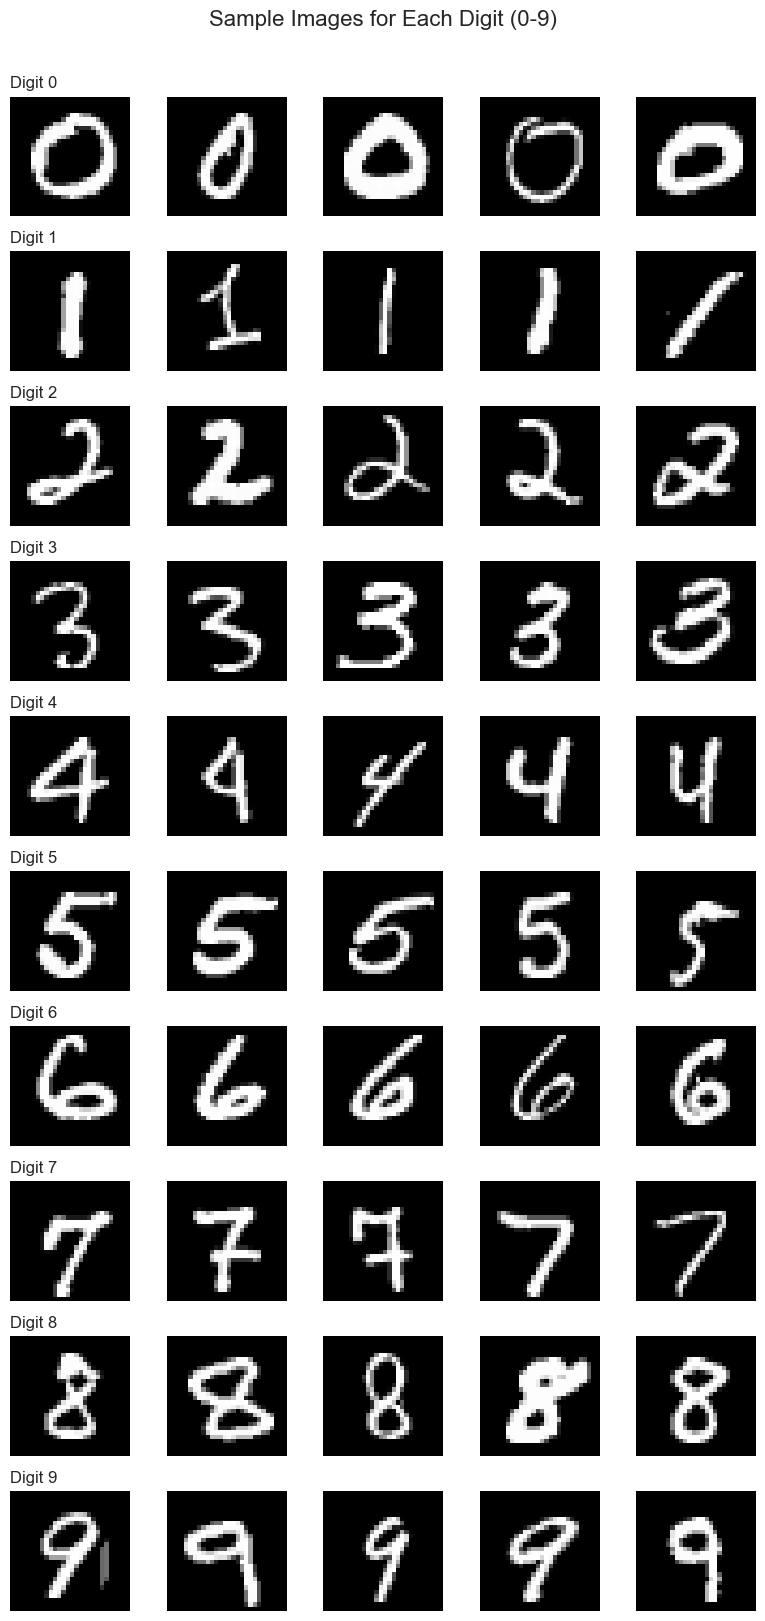

In [29]:
# Display sample images for each digit class (5 samples per digit)
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
fig.suptitle("Sample Images for Each Digit (0-9)", fontsize=16, y=1.01)

for digit in range(10):
    indices = np.where(y_train == digit)[0][:5]
    for j, idx in enumerate(indices):
        axes[digit, j].imshow(X_train[idx].reshape(28, 28), cmap='gray')
        axes[digit, j].axis('off')
        if j == 0:
            axes[digit, j].set_title(f"Digit {digit}", fontsize=12, loc='left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

### Class distribution

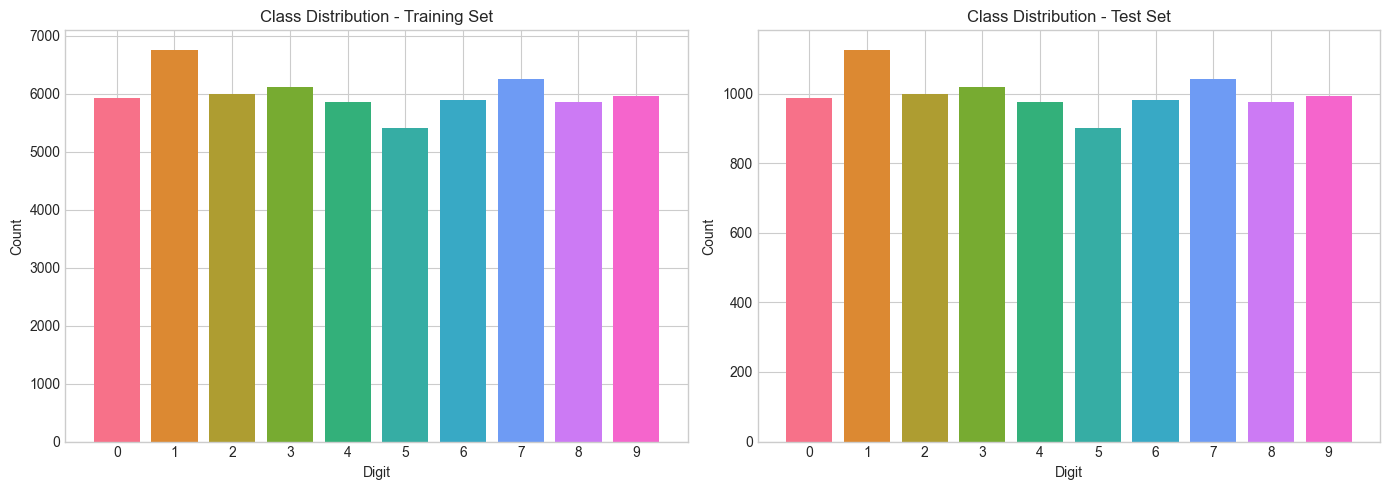

In [30]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [y_train, y_test], ['Training Set', 'Test Set']):
    unique, counts = np.unique(data, return_counts=True)
    ax.bar(unique, counts, color=sns.color_palette("husl", 10))
    ax.set_xlabel("Digit")
    ax.set_ylabel("Count")
    ax.set_title(f"Class Distribution - {title}")
    ax.set_xticks(range(10))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. KNN Grid Search on the Full Training Set

Search the full training data using a 5-fold `GridSearchCV`, then inspect every tested parameter combination and visualize the differences.

In [31]:
knn_search = run_grid_search(
    model_name='KNN',
    model_key='knn',
    pipeline=build_knn_pipeline(memory=pipeline_memory),
    param_grid=KNN_PARAM_GRID,
    X=X_train,
    y=y_train,
)

Running KNN GridSearchCV on the full training set...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components': 0.9}
Best CV accuracy: 0.9758
GridSearchCV total time: 510.77s
Estimated CV-only search time: 510.55s
GridSearchCV internal refit time: 0.22s
Best estimator:
Pipeline(memory=Memory(location=.cache/sklearn_mnist_full_search_v2),
         steps=[('pca',
                 PCA(n_components=0.9, random_state=42, svd_solver='full')),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=3,
                                      weights='distance'))])
Saved KNN search artifacts to: /Users/jiejia/Programs/MNIST-MSI/output
  - raw cv_results: output/knn_cv_results_raw_v2.csv
  - cleaned full table: output/knn_cv_results_full_v2.csv
  - ranked table: output/knn_cv_results_ranked_v2.csv
  - summary json: output/knn_search_summary_

KNN full GridSearchCV results table:


,param_knn__metric,param_knn__n_neighbors,param_knn__weights,param_pca__n_components,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time
0,euclidean,1,uniform,0.90,0.974800,0.001979,3,0.213094,0.005083
1,euclidean,1,uniform,0.95,0.972733,0.001900,12,0.217309,0.004544
2,euclidean,1,uniform,0.99,0.970917,0.002088,24,0.237400,0.004048
3,euclidean,1,distance,0.90,0.974800,0.001979,3,0.206132,0.009571
4,euclidean,1,distance,0.95,0.972733,0.001900,12,0.201727,0.003157
5,euclidean,1,distance,0.99,0.970917,0.002088,24,0.221026,0.002787
6,euclidean,3,uniform,0.90,0.974550,0.001566,6,0.188557,0.001738
7,euclidean,3,uniform,0.95,0.973333,0.002005,9,0.197454,0.002162
8,euclidean,3,uniform,0.99,0.971250,0.001941,20,0.215530,0.003170
9,euclidean,3,distance,0.90,0.975800,0.001613,1,0.189952,0.002627


KNN results sorted by rank_test_score and mean_test_score:


,param_knn__metric,param_knn__n_neighbors,param_knn__weights,param_pca__n_components,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time
0,euclidean,3,distance,0.90,0.975800,0.001613,1,0.189952,0.002627
1,euclidean,5,distance,0.90,0.975400,0.002038,2,0.193162,0.000719
2,euclidean,1,distance,0.90,0.974800,0.001979,3,0.206132,0.009571
3,euclidean,1,uniform,0.90,0.974800,0.001979,3,0.213094,0.005083
4,euclidean,3,distance,0.95,0.974767,0.002096,5,0.192866,0.005051
5,euclidean,3,uniform,0.90,0.974550,0.001566,6,0.188557,0.001738
6,euclidean,7,distance,0.90,0.973983,0.002166,7,0.195991,0.003629
7,euclidean,5,uniform,0.90,0.973833,0.001774,8,0.189570,0.002706
8,euclidean,3,uniform,0.95,0.973333,0.002005,9,0.197454,0.002162
9,euclidean,5,distance,0.95,0.972900,0.002019,10,0.199258,0.002885


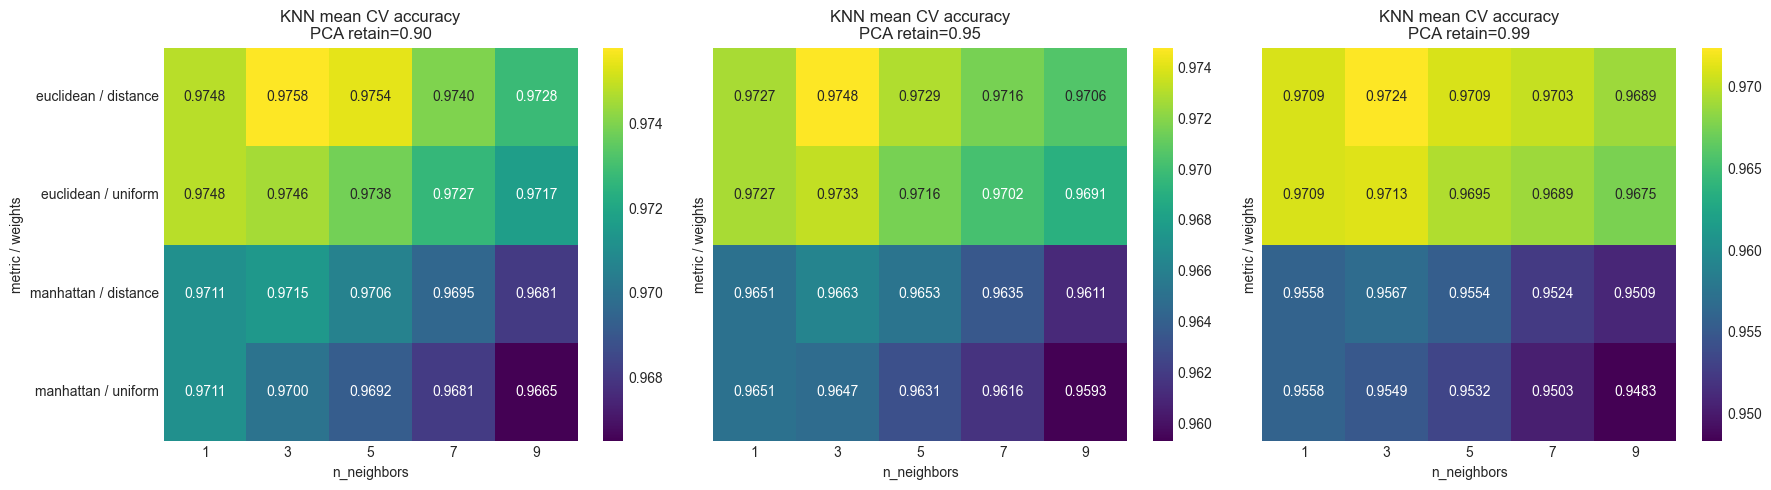

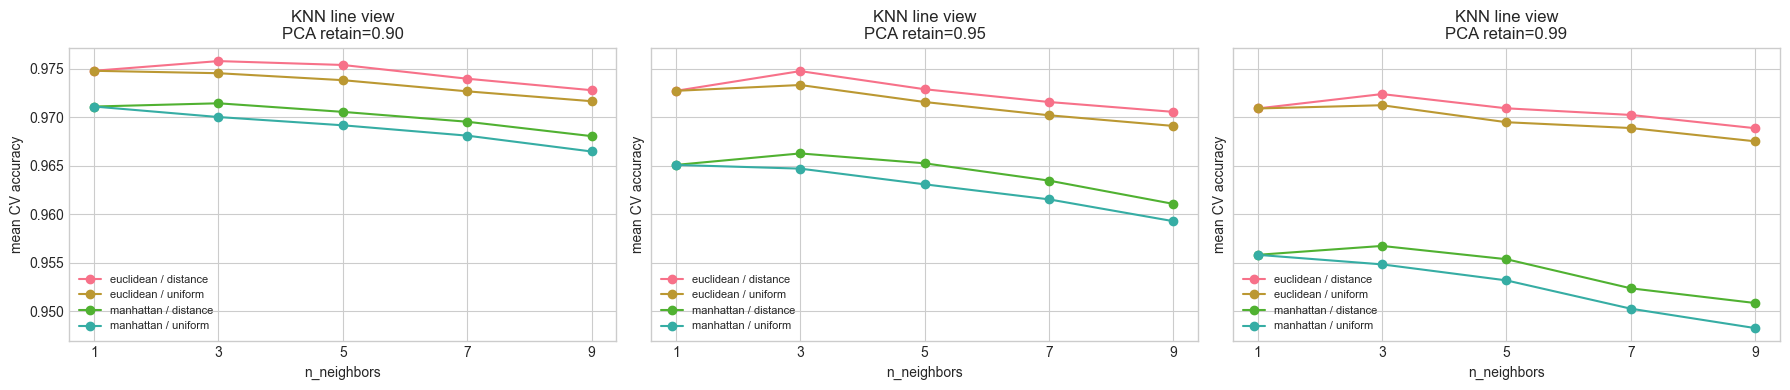

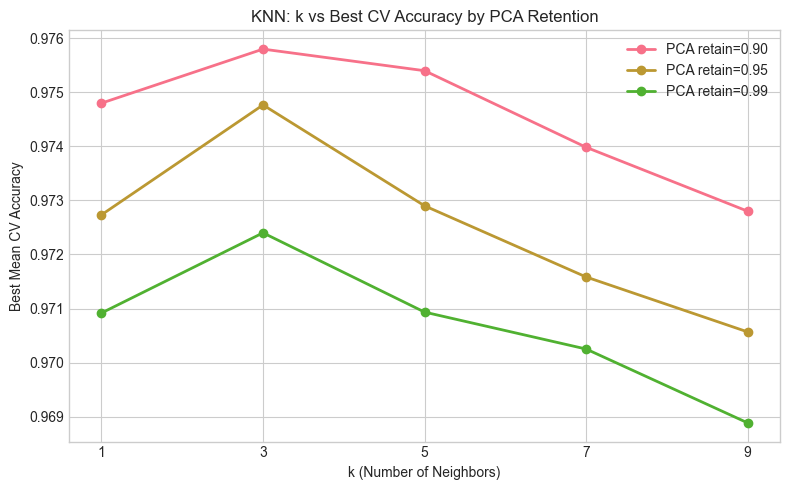

In [32]:
print('KNN full GridSearchCV results table:')
display(knn_search['full_table'])

print('KNN results sorted by rank_test_score and mean_test_score:')
display(knn_search['ranked_table'])

plot_knn_search(knn_search['cv_results_df'])

In [33]:
best_knn_params = normalize_params(knn_search['grid'].best_params_)
knn_final = clone(knn_search['grid'].best_estimator_)

sync_device()
t_start = time.time()
knn_final.fit(X_train, y_train)
sync_device()
knn_final_train_time = time.time() - t_start

sync_device()
t_start = time.time()
knn_pred = knn_final.predict(X_test)
sync_device()
knn_predict_time = time.time() - t_start

traditional_search_summaries.append({
    'Model': 'KNN',
    'Best Params': params_to_string(best_knn_params),
    'Best CV Accuracy': knn_search['grid'].best_score_,
    'Search Time (s)': knn_search['search_time'],
    'Final Train Time (s)': knn_final_train_time,
})

evaluate_model('KNN (Optimized)', y_test, knn_pred, knn_final_train_time, knn_predict_time)


KNN (Optimized) - Test Accuracy: 0.9774 (97.74%)
Training time: 0.22s | Prediction time: 0.25s

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.98      1.00      0.99      1125
           2       0.99      0.97      0.98       999
           3       0.97      0.97      0.97      1020
           4       0.99      0.96      0.98       975
           5       0.97      0.97      0.97       902
           6       0.98      0.99      0.98       982
           7       0.97      0.98      0.98      1042
           8       0.99      0.95      0.97       975
           9       0.95      0.97      0.96       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 5. Logistic Regression Grid Search on the Full Training Set

Repeat the same full-data 5-fold search pattern for Logistic Regression with its own PCA + LR pipeline.

In [34]:
lr_search = run_grid_search(
    model_name='Logistic Regression',
    model_key='lr',
    pipeline=build_lr_pipeline(memory=pipeline_memory),
    param_grid=LR_PARAM_GRID,
    X=X_train,
    y=y_train,
)

Running Logistic Regression GridSearchCV on the full training set...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs', 'pca__n_components': 0.99}
Best CV accuracy: 0.9216
GridSearchCV total time: 627.43s
Estimated CV-only search time: 626.57s
GridSearchCV internal refit time: 0.87s
Best estimator:
Pipeline(memory=Memory(location=.cache/sklearn_mnist_full_search_v2),
         steps=[('pca',
                 PCA(n_components=0.99, random_state=42, svd_solver='full')),
                ('lr',
                 LogisticRegression(C=0.1, max_iter=2000, penalty='l2',
                                    random_state=42))])
Saved Logistic Regression search artifacts to: /Users/jiejia/Programs/MNIST-MSI/output
  - raw cv_results: output/lr_cv_results_raw_v2.csv
  - cleaned full table: output/lr_cv_results_full_v2.csv
  - ranked table: output/lr_cv_results_ranked_v2.csv
  - summary json: output/lr_search_summar

Logistic Regression full GridSearchCV results table:


,param_lr__C,param_lr__penalty,param_lr__solver,param_pca__n_components,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time
0,0.01,l2,lbfgs,0.90,0.909633,0.002960,24,0.697314,0.009650
1,0.01,l2,lbfgs,0.95,0.912250,0.002427,21,0.873534,0.029972
2,0.01,l2,lbfgs,0.99,0.913283,0.002704,20,1.204317,0.017216
3,0.01,l2,saga,0.90,0.909717,0.002887,23,1.433665,0.015790
4,0.01,l2,saga,0.95,0.912167,0.002385,22,2.207331,0.023005
5,0.01,l2,saga,0.99,0.913417,0.002603,19,4.369904,0.137952
6,0.10,l2,lbfgs,0.90,0.915583,0.002742,17,0.568267,0.027493
7,0.10,l2,lbfgs,0.95,0.919417,0.001322,11,0.792940,0.073770
8,0.10,l2,lbfgs,0.99,0.921567,0.002338,1,1.315852,0.074675
9,0.10,l2,saga,0.90,0.915583,0.002637,17,3.843963,0.399602


Logistic Regression results sorted by rank_test_score and mean_test_score:


,param_lr__C,param_lr__penalty,param_lr__solver,param_pca__n_components,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time
0,0.10,l2,lbfgs,0.99,0.921567,0.002338,1,1.315852,0.074675
1,0.10,l2,saga,0.99,0.921483,0.002237,2,17.245037,1.455796
2,1.00,l2,saga,0.99,0.921417,0.002816,3,608.223913,3.485870
3,1.00,l2,lbfgs,0.99,0.921350,0.002662,4,2.297752,0.095838
4,10.00,l2,lbfgs,0.95,0.920233,0.001798,5,1.211871,0.040465
5,10.00,l2,saga,0.95,0.920217,0.001950,6,43.322917,4.925964
6,1.00,l2,saga,0.95,0.920100,0.001569,7,337.411844,1.183090
7,10.00,l2,saga,0.99,0.919850,0.002718,8,182.421765,4.470806
8,1.00,l2,lbfgs,0.95,0.919817,0.001510,9,0.982292,0.089946
9,10.00,l2,lbfgs,0.99,0.919500,0.002330,10,2.717801,0.097855


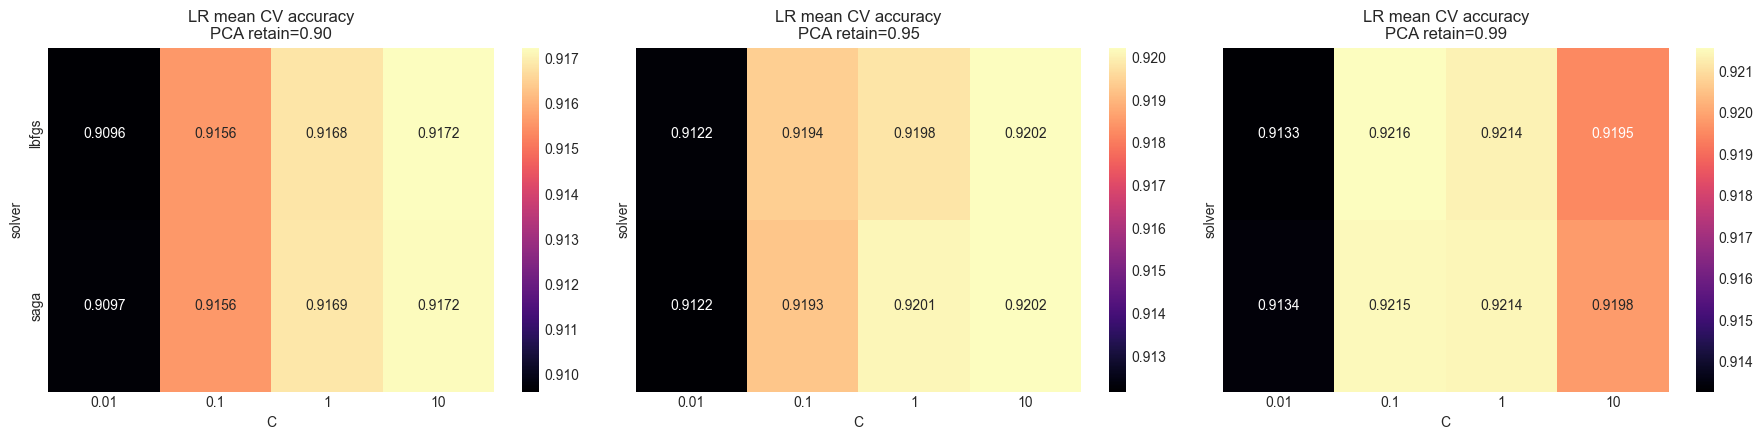

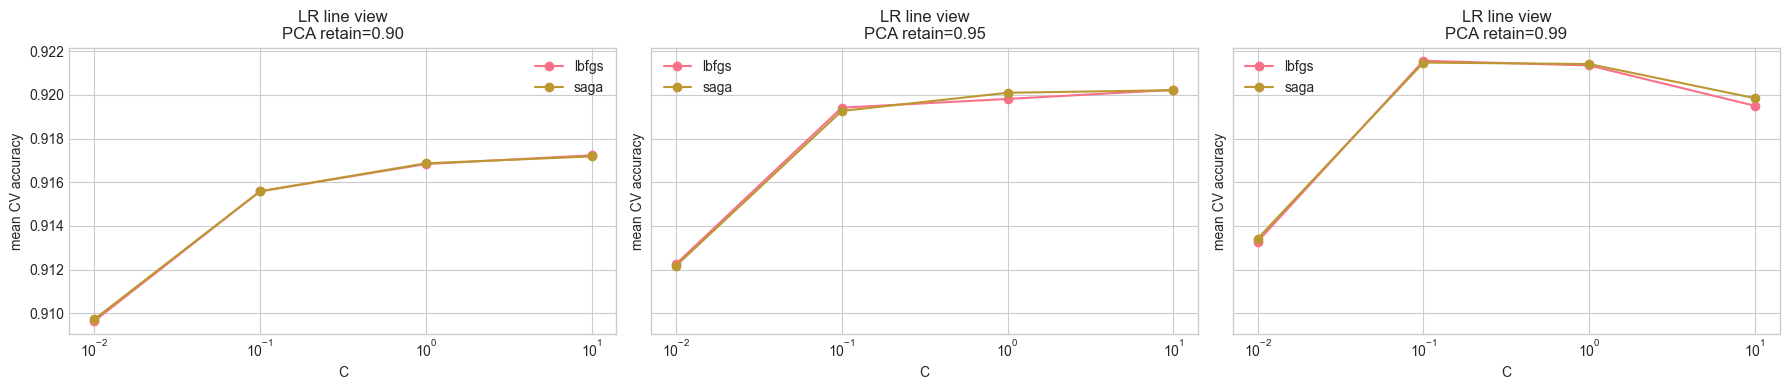

In [35]:
print('Logistic Regression full GridSearchCV results table:')
display(lr_search['full_table'])

print('Logistic Regression results sorted by rank_test_score and mean_test_score:')
display(lr_search['ranked_table'])

plot_lr_search(lr_search['cv_results_df'])

In [36]:
best_lr_params = normalize_params(lr_search['grid'].best_params_)
lr_final = clone(lr_search['grid'].best_estimator_)

sync_device()
t_start = time.time()
lr_final.fit(X_train, y_train)
sync_device()
lr_final_train_time = time.time() - t_start

sync_device()
t_start = time.time()
lr_pred = lr_final.predict(X_test)
sync_device()
lr_predict_time = time.time() - t_start

traditional_search_summaries.append({
    'Model': 'Logistic Regression',
    'Best Params': params_to_string(best_lr_params),
    'Best CV Accuracy': lr_search['grid'].best_score_,
    'Search Time (s)': lr_search['search_time'],
    'Final Train Time (s)': lr_final_train_time,
})

evaluate_model('Logistic Regression (Optimized)', y_test, lr_pred, lr_final_train_time, lr_predict_time)


Logistic Regression (Optimized) - Test Accuracy: 0.9227 (92.27%)
Training time: 0.86s | Prediction time: 0.01s

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       986
           1       0.95      0.98      0.96      1125
           2       0.92      0.90      0.91       999
           3       0.90      0.89      0.89      1020
           4       0.93      0.93      0.93       975
           5       0.88      0.88      0.88       902
           6       0.93      0.96      0.95       982
           7       0.95      0.94      0.94      1042
           8       0.90      0.87      0.89       975
           9       0.89      0.91      0.90       994

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## 6. Neural Network Data Preparation

Split the training set into train / validation subsets for MLP and CNN training. CNN augmentation is applied per sample inside a custom dataset.

In [37]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train,
)

X_tr_tensor = torch.from_numpy(X_tr).float()
y_tr_tensor = torch.from_numpy(y_tr).long()
X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).long()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

class AugmentedDataset(Dataset):
    def __init__(self, X_tensor, y_tensor, transform=None):
        self.X = X_tensor
        self.y = y_tensor
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].view(1, 28, 28)
        if self.transform is not None:
            x = self.transform(x)
        return x.view(-1), self.y[idx]

cnn_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
train_dataset_aug = AugmentedDataset(X_tr_tensor, y_tr_tensor, transform=cnn_augment)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0,
)
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED + 1),
    num_workers=0,
)
val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')
print('CNN data augmentation: RandomRotation(±10°) + RandomAffine(translate=10%)')
print('MLP data augmentation: inline Gaussian noise with std=0.05 during training')

Train: 54000, Val: 6000, Test: 10000
CNN data augmentation: RandomRotation(±10°) + RandomAffine(translate=10%)
MLP data augmentation: inline Gaussian noise with std=0.05 during training


In [38]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.network(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

print('MLP architecture:')
print(MLP())
print('\nCNN architecture:')
print(CNN())

MLP architecture:
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

CNN architecture:
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_s

In [39]:
def metric_strictly_improved(current, best, mode):
    if best is None:
        return True
    if mode == 'max':
        return current > best
    if mode == 'min':
        return current < best
    raise ValueError(f'Unsupported mode: {mode}')

def metric_improved_by_delta(current, best, mode, min_delta):
    if best is None:
        return True
    if mode == 'max':
        return current > best + min_delta
    if mode == 'min':
        return current < best - min_delta
    raise ValueError(f'Unsupported mode: {mode}')

def train_nn(model, train_loader, val_loader, epochs, lr, model_name, early_stop_config):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=NN_WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_metric = None
    best_model_state = None
    best_epoch = 0
    early_stop_best_metric = None
    patience_counter = 0
    stopped_early = False

    use_early_stopping = early_stop_config['use_early_stopping']
    monitor = early_stop_config['monitor']
    mode = early_stop_config['mode']
    min_delta = early_stop_config['min_delta']
    patience = early_stop_config['patience']
    restore_best_weights = early_stop_config['restore_best_weights']
    min_epochs = early_stop_config['min_epochs']

    print(f'{model_name} early stopping config: {early_stop_config}')
    print(f'{model_name} checkpoint rule: save on any strict {monitor} improvement; early stopping uses min_delta={min_delta}.')
    print(f'{model_name} optimizer: {NN_OPTIMIZER_NAME} | lr={lr} | weight_decay={NN_WEIGHT_DECAY}')

    sync_device()
    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if model_name == 'MLP':
                X_batch = X_batch + torch.randn_like(X_batch) * 0.05
                X_batch = X_batch.clamp(0, 1)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_correct += (output.argmax(1) == y_batch).sum().item()
            train_total += X_batch.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (output.argmax(1) == y_batch).sum().item()
                val_total += X_batch.size(0)

        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        metrics = {
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
        }
        current_metric = metrics[monitor]

        print(
            f'Epoch {epoch + 1:2d}/{epochs} | '
            f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
            f'LR: {current_lr:.6f}'
        )

        if metric_strictly_improved(current_metric, best_metric, mode):
            best_metric = current_metric
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        if metric_improved_by_delta(current_metric, early_stop_best_metric, mode, min_delta):
            early_stop_best_metric = current_metric
            patience_counter = 0
        else:
            if use_early_stopping and (epoch + 1) >= min_epochs:
                patience_counter += 1
                if patience_counter >= patience:
                    stopped_early = True
                    print(
                        f'Early stopping at epoch {epoch + 1} '
                        f'after {patience} epochs without a {monitor} improvement larger than {min_delta}.'
                    )
                    break

    sync_device()
    train_time = time.time() - t_start

    if restore_best_weights and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f'Restored best checkpoint from epoch {best_epoch} ({monitor}={best_metric:.4f})')

    train_info = {
        'best_epoch': best_epoch,
        'best_metric': best_metric,
        'monitor': monitor,
        'stopped_early': stopped_early,
        'early_stop_best_metric': early_stop_best_metric,
    }
    return model, history, train_time, train_info

def predict_nn(model, test_loader):
    model.eval()
    all_preds = []
    sync_device()
    t_start = time.time()
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            all_preds.append(output.argmax(1).cpu())
    sync_device()
    predict_time = time.time() - t_start
    return torch.cat(all_preds).numpy(), predict_time


## 7. Train the Neural Networks with Configurable Early Stopping

The MLP and CNN share the same training loop, but each model uses its own default early-stopping configuration.

In [40]:
USE_EARLY_STOPPING = False
RESTORE_BEST_WEIGHTS = True
MIN_EPOCHS = 5
NN_WEIGHT_DECAY = 1e-4
NN_EPOCHS = 50
NN_LR = 0.0005
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512

In [41]:
print('=' * 80)
print('Training MLP...')
print('=' * 80)

mlp_model = MLP()
mlp_model, mlp_history, mlp_train_time, mlp_train_info = train_nn(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=NN_EPOCHS,
    lr=NN_LR,
    model_name='MLP',
    early_stop_config=MLP_EARLY_STOP_CONFIG,
)

mlp_pred, mlp_predict_time = predict_nn(mlp_model, test_loader)
evaluate_model('MLP (Neural Network)', y_test, mlp_pred, mlp_train_time, mlp_predict_time)

Training MLP...
MLP early stopping config: {'use_early_stopping': False, 'monitor': 'val_acc', 'mode': 'max', 'min_delta': 0.000333, 'patience': 8, 'restore_best_weights': True, 'min_epochs': 5}
MLP checkpoint rule: save on any strict val_acc improvement; early stopping uses min_delta=0.000333.
MLP optimizer: AdamW | lr=0.0005 | weight_decay=0.0001
Epoch  1/50 | Train Loss: 0.4848 Acc: 0.8858 | Val Loss: 0.1390 Acc: 0.9607 | LR: 0.000500
Epoch  2/50 | Train Loss: 0.1633 Acc: 0.9543 | Val Loss: 0.0965 Acc: 0.9715 | LR: 0.000500
Epoch  3/50 | Train Loss: 0.1180 Acc: 0.9655 | Val Loss: 0.0787 Acc: 0.9773 | LR: 0.000500
Epoch  4/50 | Train Loss: 0.0941 Acc: 0.9717 | Val Loss: 0.0710 Acc: 0.9785 | LR: 0.000500
Epoch  5/50 | Train Loss: 0.0805 Acc: 0.9751 | Val Loss: 0.0654 Acc: 0.9795 | LR: 0.000500
Epoch  6/50 | Train Loss: 0.0676 Acc: 0.9795 | Val Loss: 0.0758 Acc: 0.9782 | LR: 0.000500
Epoch  7/50 | Train Loss: 0.0605 Acc: 0.9810 | Val Loss: 0.0641 Acc: 0.9815 | LR: 0.000500
Epoch  8/50 

In [42]:
print('=' * 80)
print('Training CNN...')
print('=' * 80)

cnn_model = CNN()
cnn_model, cnn_history, cnn_train_time, cnn_train_info = train_nn(
    model=cnn_model,
    train_loader=train_loader_aug,
    val_loader=val_loader,
    epochs=NN_EPOCHS,
    lr=NN_LR,
    model_name='CNN',
    early_stop_config=CNN_EARLY_STOP_CONFIG,
)

cnn_pred, cnn_predict_time = predict_nn(cnn_model, test_loader)
evaluate_model('CNN (Neural Network)', y_test, cnn_pred, cnn_train_time, cnn_predict_time)

Training CNN...
CNN early stopping config: {'use_early_stopping': False, 'monitor': 'val_acc', 'mode': 'max', 'min_delta': 0.000333, 'patience': 12, 'restore_best_weights': True, 'min_epochs': 5}
CNN checkpoint rule: save on any strict val_acc improvement; early stopping uses min_delta=0.000333.
CNN optimizer: AdamW | lr=0.0005 | weight_decay=0.0001
Epoch  1/50 | Train Loss: 0.4296 Acc: 0.8840 | Val Loss: 0.0756 Acc: 0.9802 | LR: 0.000500
Epoch  2/50 | Train Loss: 0.1186 Acc: 0.9675 | Val Loss: 0.0369 Acc: 0.9907 | LR: 0.000500
Epoch  3/50 | Train Loss: 0.0855 Acc: 0.9756 | Val Loss: 0.0299 Acc: 0.9917 | LR: 0.000500
Epoch  4/50 | Train Loss: 0.0717 Acc: 0.9791 | Val Loss: 0.0284 Acc: 0.9905 | LR: 0.000500
Epoch  5/50 | Train Loss: 0.0636 Acc: 0.9806 | Val Loss: 0.0234 Acc: 0.9932 | LR: 0.000500
Epoch  6/50 | Train Loss: 0.0571 Acc: 0.9824 | Val Loss: 0.0196 Acc: 0.9935 | LR: 0.000500
Epoch  7/50 | Train Loss: 0.0518 Acc: 0.9841 | Val Loss: 0.0209 Acc: 0.9927 | LR: 0.000500
Epoch  8/50

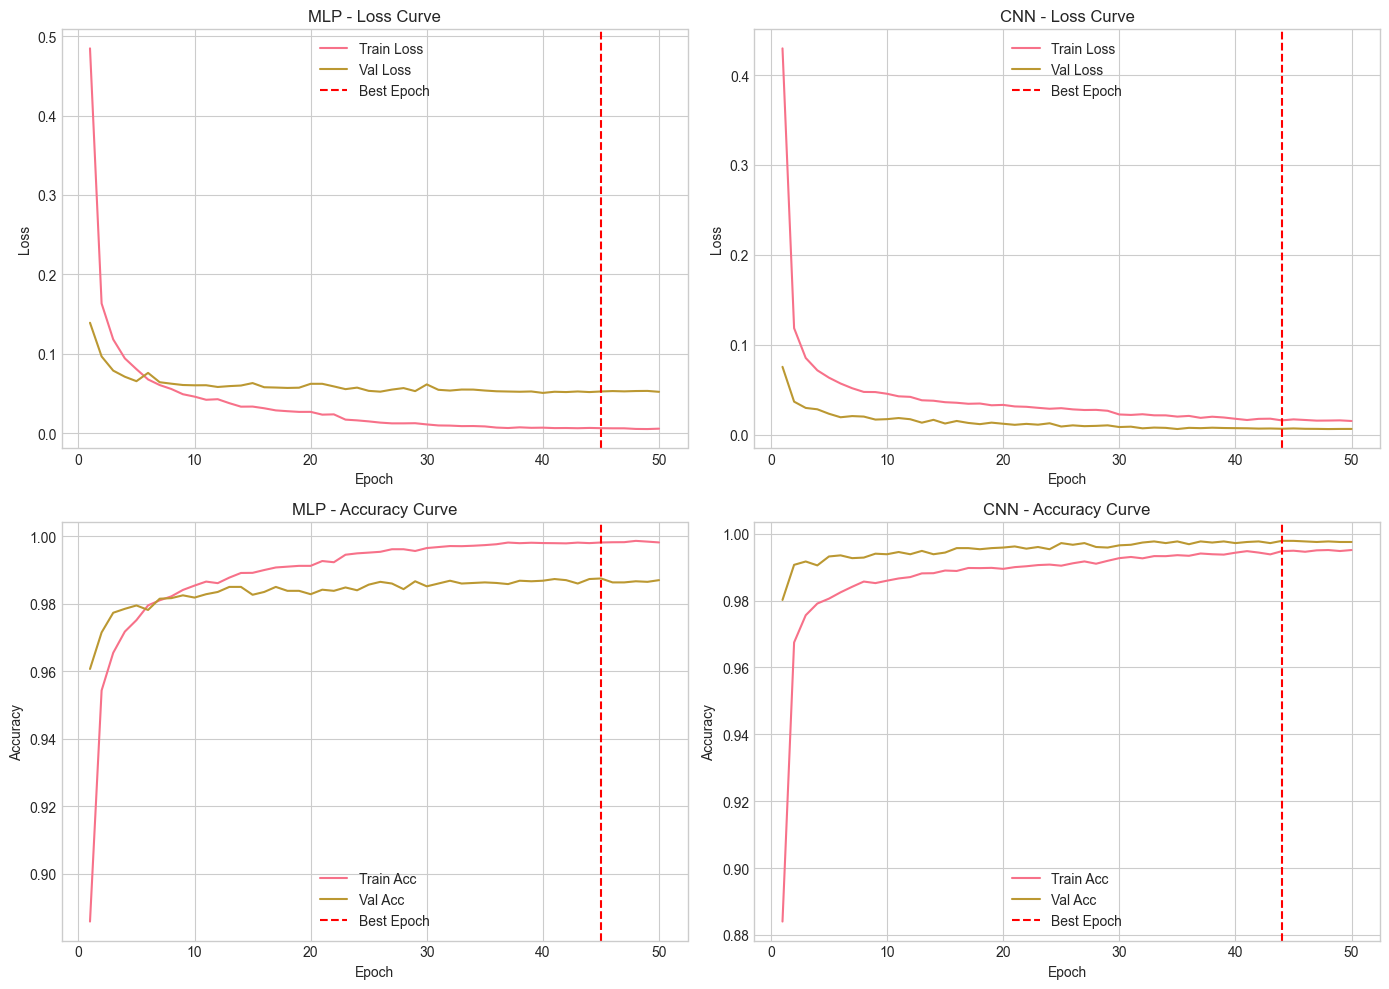

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (history, info, name) in enumerate([
    (mlp_history, mlp_train_info, 'MLP'),
    (cnn_history, cnn_train_info, 'CNN'),
]):
    epochs_range = range(1, len(history['train_loss']) + 1)
    best_epoch = info['best_epoch']

    axes[0, idx].plot(epochs_range, history['train_loss'], label='Train Loss')
    axes[0, idx].plot(epochs_range, history['val_loss'], label='Val Loss')
    if best_epoch:
        axes[0, idx].axvline(best_epoch, color='red', linestyle='--', label='Best Epoch')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].set_title(f'{name} - Loss Curve')
    axes[0, idx].legend()

    axes[1, idx].plot(epochs_range, history['train_acc'], label='Train Acc')
    axes[1, idx].plot(epochs_range, history['val_acc'], label='Val Acc')
    if best_epoch:
        axes[1, idx].axvline(best_epoch, color='red', linestyle='--', label='Best Epoch')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].set_title(f'{name} - Accuracy Curve')
    axes[1, idx].legend()

plt.tight_layout()
plt.savefig(OUTPUT_FILES['nn_curves'], dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Result Tables and Visualizations

Summarize traditional-model search results, compare final model performance, and draw confusion matrices.

Traditional model search summary:


,Model,Best Params,Best CV Accuracy,Search Time (s),Final Train Time (s)
0,KNN,"{""knn__metric"": ""euclidean"", ""knn__n_neighbors"": 3, ""knn__weights"": ""distance"", ""pca__n_components"": 0.9}",0.9758,510.5490,0.2167
1,Logistic Regression,"{""lr__C"": 0.1, ""lr__penalty"": ""l2"", ""lr__solver"": ""lbfgs"", ""pca__n_components"": 0.99}",0.9216,626.5652,0.8647


Final model comparison:


,Model,Accuracy (%),Train Time (s),Predict Time (s)
0,CNN (Neural Network),99.65,347.2937,0.0663
1,MLP (Neural Network),98.72,32.1945,0.0241
2,KNN (Optimized),97.74,0.2167,0.2526
3,Logistic Regression (Optimized),92.27,0.8647,0.0079


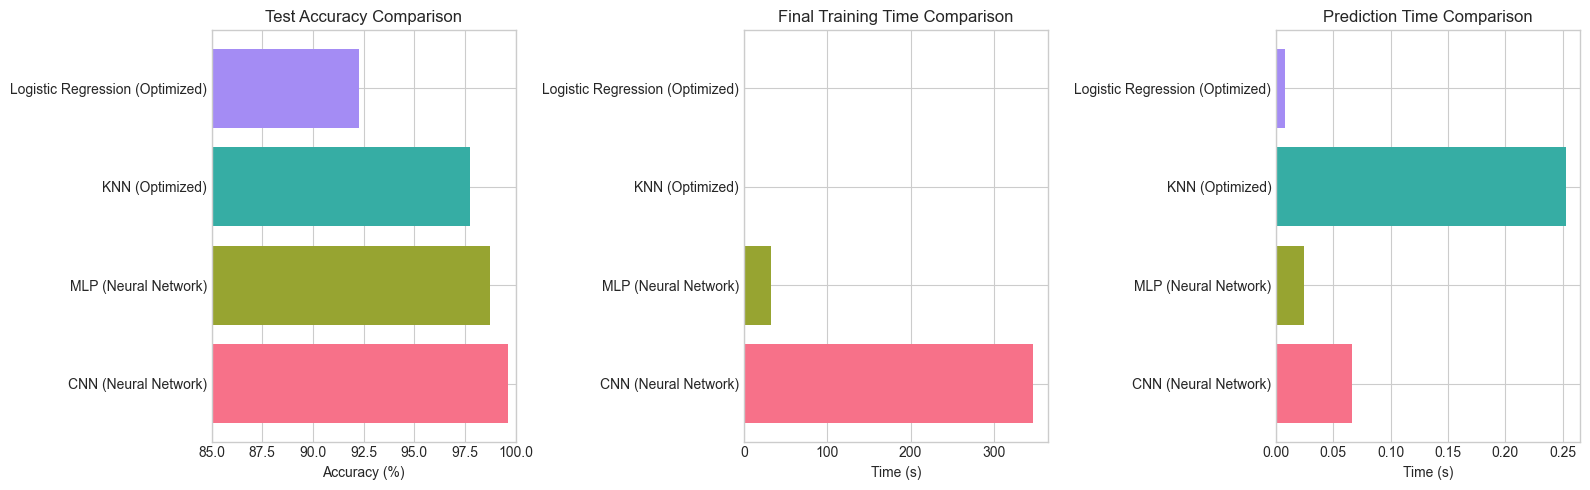

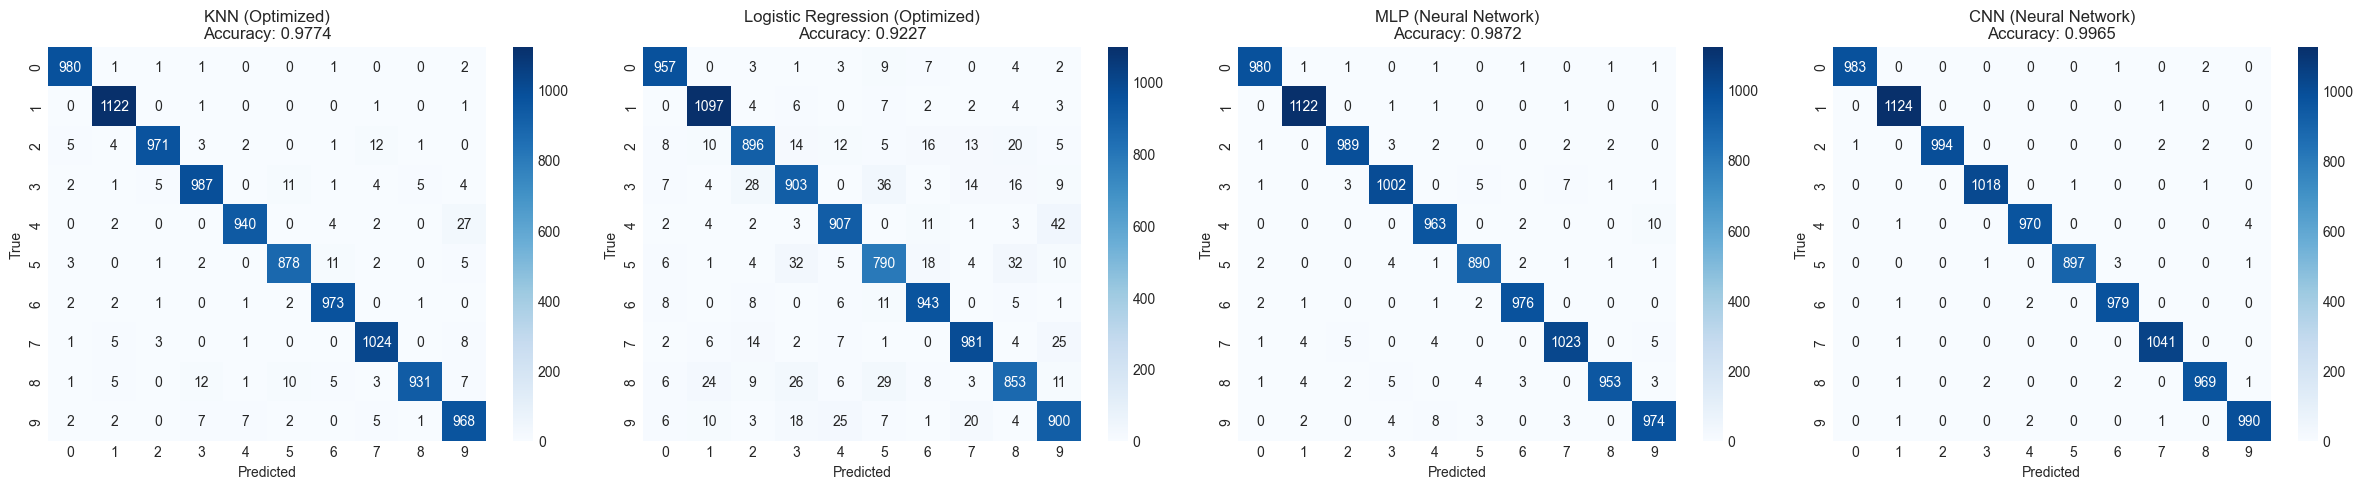

Best model: CNN (Neural Network) with 99.65% accuracy


In [44]:
traditional_search_summary_df = pd.DataFrame(traditional_search_summaries)
if not traditional_search_summary_df.empty:
    traditional_search_summary_df['Best CV Accuracy'] = traditional_search_summary_df['Best CV Accuracy'].round(4)
    traditional_search_summary_df['Search Time (s)'] = traditional_search_summary_df['Search Time (s)'].round(4)
    traditional_search_summary_df['Final Train Time (s)'] = traditional_search_summary_df['Final Train Time (s)'].round(4)

print('Traditional model search summary:')
display(traditional_search_summary_df)

model_names = list(results.keys())
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy (%)': [results[name]['accuracy'] * 100 for name in model_names],
    'Train Time (s)': [results[name]['train_time'] for name in model_names],
    'Predict Time (s)': [results[name]['predict_time'] for name in model_names],
}).round(4)
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print('Final model comparison:')
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette('husl', len(comparison_df))

axes[0].barh(comparison_df['Model'], comparison_df['Accuracy (%)'], color=palette)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_xlim(85, 100)

axes[1].barh(comparison_df['Model'], comparison_df['Train Time (s)'], color=palette)
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Final Training Time Comparison')

axes[2].barh(comparison_df['Model'], comparison_df['Predict Time (s)'], color=palette)
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Prediction Time Comparison')

plt.tight_layout()
plt.savefig(OUTPUT_FILES['model_comparison'], dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5))
if len(model_names) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.4f}')

plt.tight_layout()
plt.savefig(OUTPUT_FILES['confusion_matrices'], dpi=150, bbox_inches='tight')
plt.show()

print(f"Best model: {comparison_df.iloc[0]['Model']} with {comparison_df.iloc[0]['Accuracy (%)']:.2f}% accuracy")

## 9. Dimensionality Reduction & Visualization

In [45]:
from sklearn.manifold import TSNE

# Use a subset for visualization (t-SNE is computationally expensive)
viz_size = 10000
viz_indices = np.random.RandomState(42).choice(len(X_train), viz_size, replace=False)
X_viz = X_train[viz_indices]
y_viz = y_train[viz_indices]

# PCA to 2D
print("Applying PCA...")
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_viz)
print(f"PCA explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum():.4f}")

# t-SNE to 2D (use PCA to 50D first for speed)
print("\nApplying t-SNE (this may take a few minutes)...")
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_viz)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, learning_rate='auto', init='pca')
X_tsne_2d = tsne.fit_transform(X_pca_50)
print("t-SNE complete.")

Applying PCA...
PCA explained variance ratio: [0.09541446 0.07158288]
Total variance explained: 0.1670

Applying t-SNE (this may take a few minutes)...
t-SNE complete.


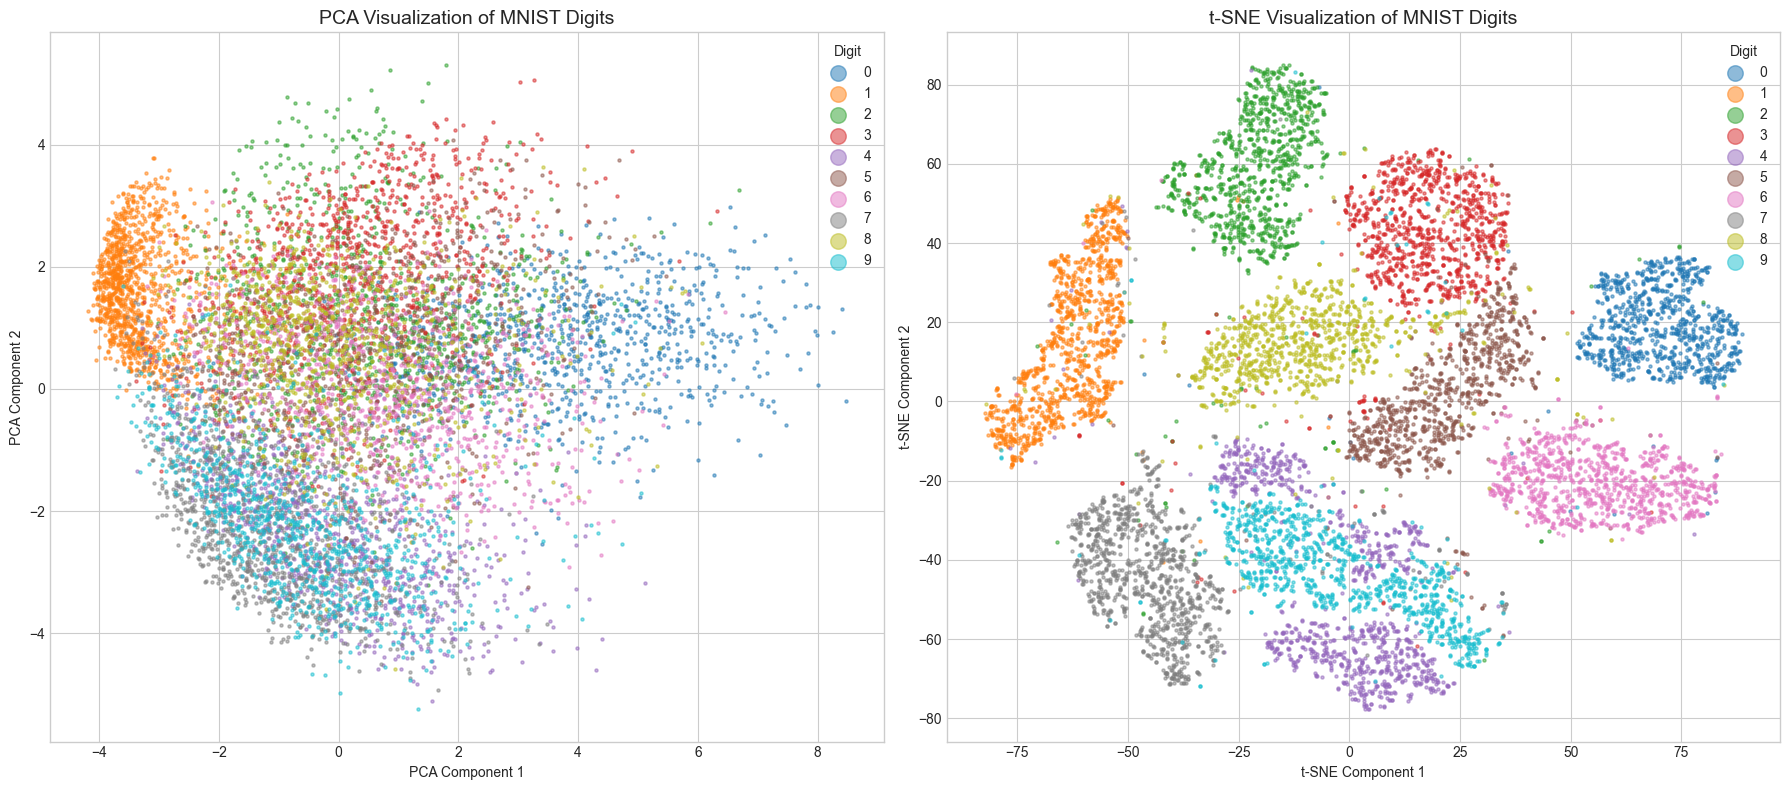

In [46]:
# Plot PCA and t-SNE side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, X_2d, title in zip(axes, [X_pca_2d, X_tsne_2d], ['PCA', 't-SNE']):
    for digit in range(10):
        mask = y_viz == digit
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                   c=[colors[digit]], label=str(digit), 
                   alpha=0.5, s=5)
    ax.set_title(f'{title} Visualization of MNIST Digits', fontsize=14)
    ax.set_xlabel(f'{title} Component 1')
    ax.set_ylabel(f'{title} Component 2')
    ax.legend(title='Digit', markerscale=5, loc='best')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dimensionality_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

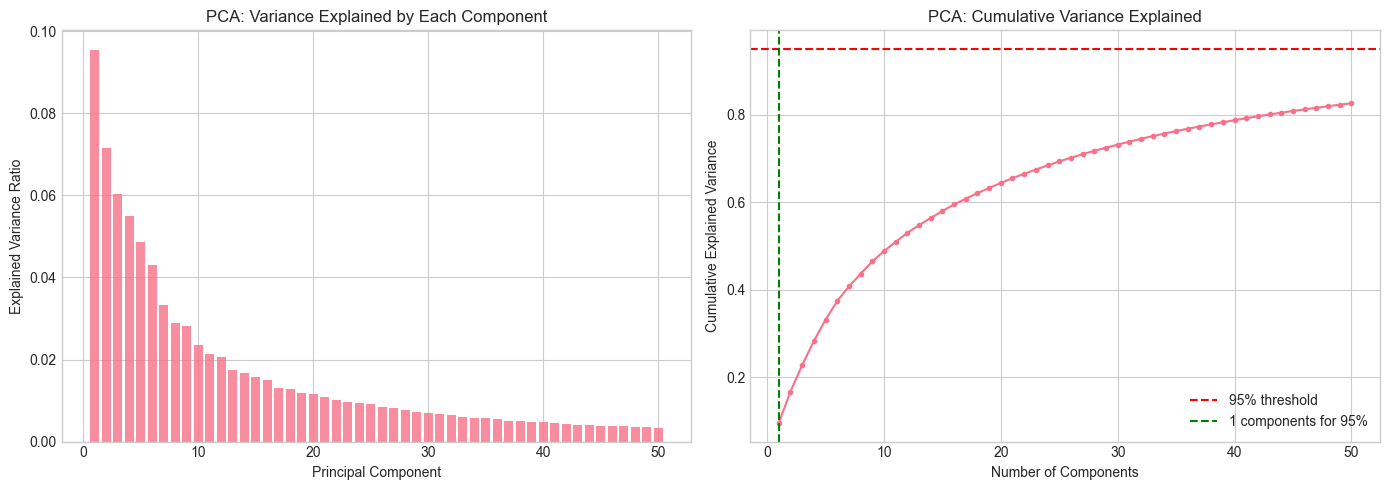

Components needed for 95% variance: 1


In [47]:
# PCA variance explained analysis
pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(X_viz)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_, alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Variance Explained by Each Component')

# Cumulative variance
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 51), cumulative_var, marker='o', markersize=3)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
n_95 = np.argmax(cumulative_var >= 0.95) + 1
axes[1].axvline(x=n_95, color='g', linestyle='--', label=f'{n_95} components for 95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Components needed for 95% variance: {n_95}")

### Interpretation of Clustering Patterns

**PCA Visualization:**
- PCA preserves global structure but clusters overlap significantly in 2D, because the first two principal components only capture a limited portion of total variance.
- Despite overlap, some digits (e.g., 0 and 1) are relatively well separated, while others (e.g., 4 and 9, 3 and 5) show significant overlap, indicating visual similarity.

**t-SNE Visualization:**
- t-SNE produces much clearer, well-separated clusters for each digit class.
- It reveals the local neighborhood structure: similar-looking digits are grouped tightly together.
- Digits that are commonly confused (e.g., 4/9, 3/5, 7/1) may have overlapping regions in the t-SNE plot, which aligns with the confusion matrix results.
- t-SNE is non-linear and better at preserving local structure, making it superior for visualization of high-dimensional data clusters.

**PCA vs t-SNE:**
- PCA is a linear method that maximizes variance — fast but limited in revealing non-linear structure.
- t-SNE is non-linear and focuses on preserving local similarities — much better for visualization but computationally expensive and non-deterministic.